In [1]:
import pandas as pd
import json
import yaml
from pathlib import Path
import sys
from IPython.display import display, HTML, Image, Markdown
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sys.path.append('../')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)    

## Cargado de los resultados de todos los experimentos

Si los experimentos tienen nombres distintos en los archivos JSON o la imagen no funcionará.

In [2]:
EXPERIMENTS_DIR = Path('../experiments')

all_metrics = []
experiment_artifacts = []
CLASS_NAMES = ['Normal', 'Robbery']

print(f"Buscando experimentos en {EXPERIMENTS_DIR.resolve()}")

for exp_dir in EXPERIMENTS_DIR.iterdir():
    if not exp_dir.is_dir():
        continue

    exp_name = exp_dir.name

    metrics_path = exp_dir / 'results' / 'tables' / 'lstm_final_metrics.json'
    preds_path = exp_dir / 'results' / 'tables' / 'lstm_test_predictions.json'
    plot_path = exp_dir / 'results' / 'plots' / '2_classification_analysis.png'

    if metrics_path.exists() and preds_path.exists():
        print(f"Cargando datos de {exp_name}")
        try:
            with open(metrics_path, 'r') as f:
                final_metrics = json.load(f)

            with open(preds_path, 'r') as f:
                test_predictions = json.load(f)
            
            y_true = test_predictions['labels']
            y_pred = test_predictions['preds']

            test_metrics_global = final_metrics.get('test_metrics', {})
            auc_score = test_metrics_global.get('auc', 0.0)

            report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

            robbery_metrics = report_dict.get('Robbery', {})
            robbery_recall = robbery_metrics.get('recall', 0.0)
            robbery_f1 = robbery_metrics.get('f1-score', 0.0)
            robbery_precision = robbery_metrics.get('precision', 0.0)

            all_metrics.append({
                'Experimento': exp_name,
                'AUC (Test)': auc_score,
                'F1 (Robbery)': robbery_f1,
                'Recall (Robbery)': robbery_recall,
                'Precision (Robbery)': robbery_precision,
                'Accuracy (Global)': test_metrics_global.get('accuracy', 0.0)
            })

            experiment_artifacts.append({
                'name': exp_name,
                'global_metrics': test_metrics_global,
                'classification_report': classification_report(y_true, y_pred, target_names=CLASS_NAMES),
                'plot_path': plot_path if plot_path.exists() else None
            })
        except Exception as e:
            print(f"Error al cargar {exp_name}: {e}")

Buscando experimentos en D:\Dataset\experiments
Cargando datos de exp_01
Cargando datos de exp_02
Cargando datos de exp_03
Cargando datos de exp_04
Cargando datos de exp_05
Cargando datos de exp_06
Cargando datos de exp_07
Cargando datos de exp_08
Cargando datos de exp_09
Cargando datos de exp_10
Cargando datos de exp_11
Cargando datos de exp_12
Cargando datos de exp_13


## Visualización de resultados individuales

,Valor
Métrica,
loss,0.5509
accuracy,0.7344
precision,0.6333
recall,0.7600
f1_score,0.6909
auc,0.8133


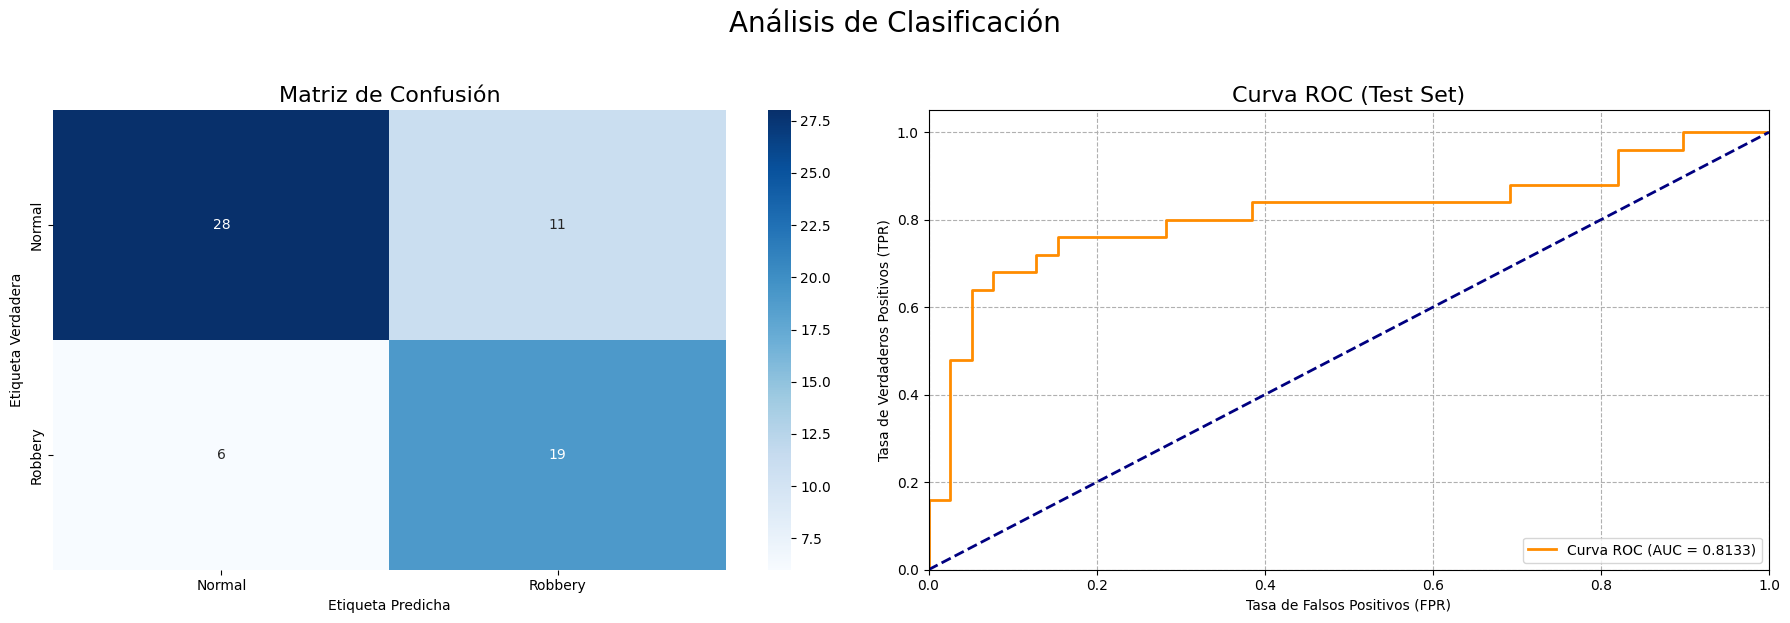

,Valor
Métrica,
loss,0.6154
accuracy,0.7969
precision,0.7143
recall,0.8000
f1_score,0.7547
auc,0.8667


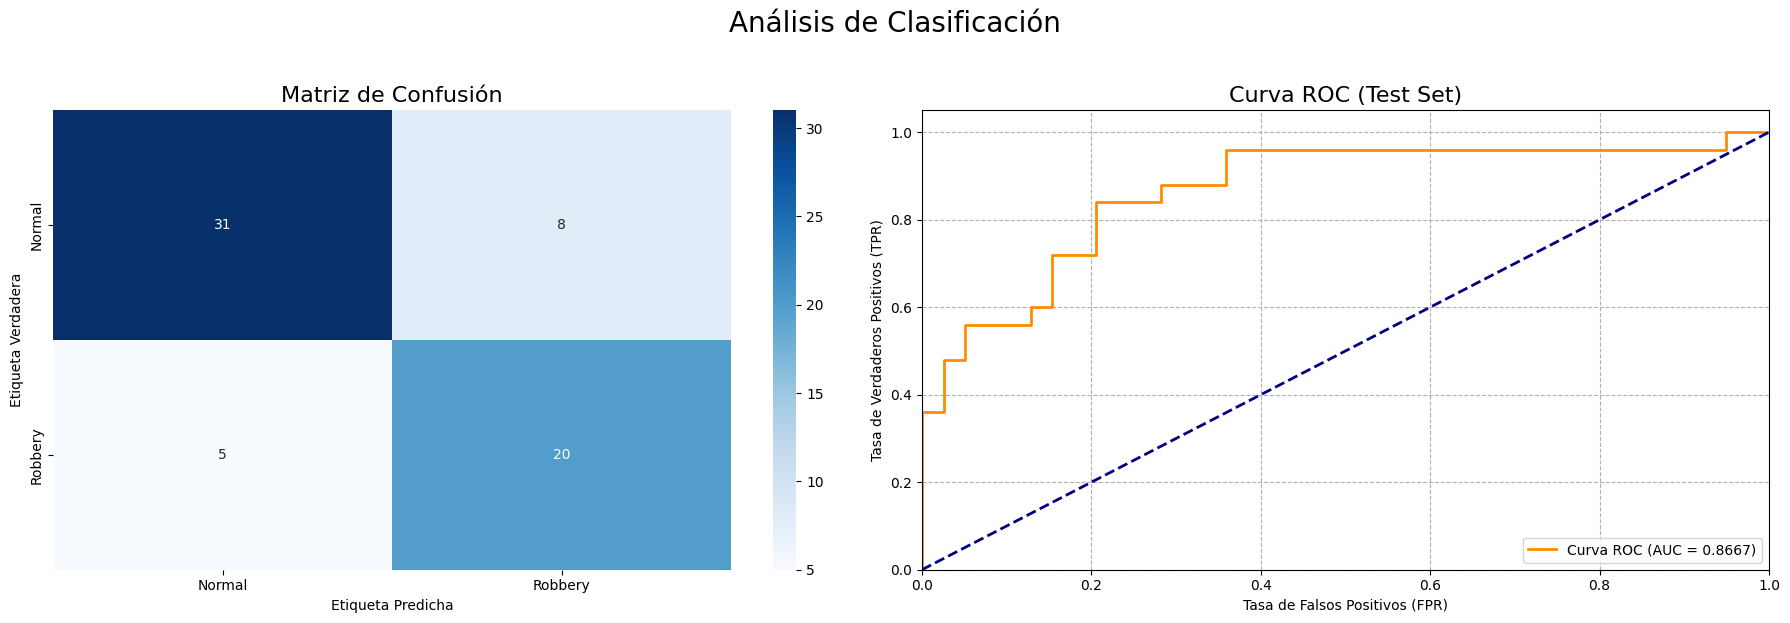

,Valor
Métrica,
loss,0.6027
accuracy,0.7969
precision,0.7308
recall,0.7600
f1_score,0.7451
auc,0.7887


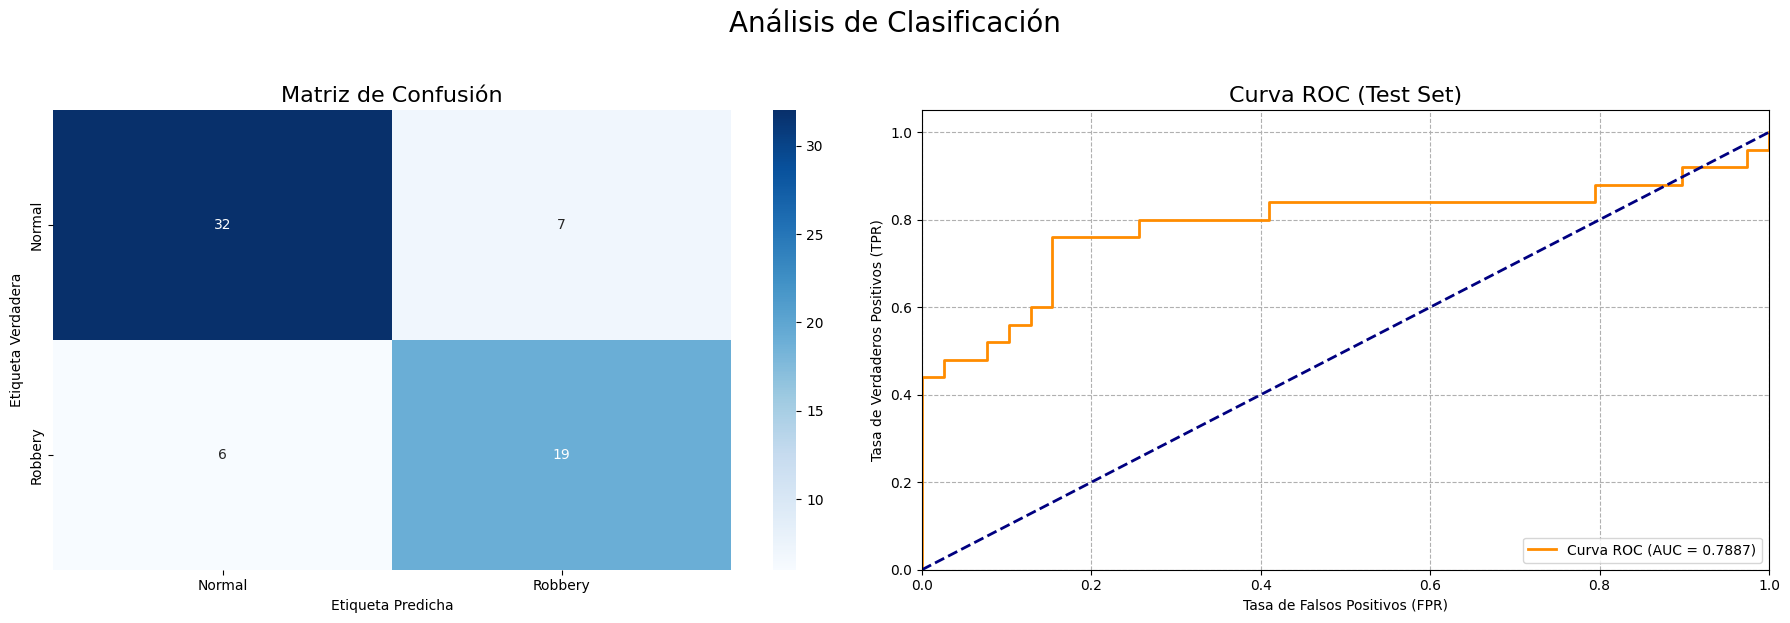

,Valor
Métrica,
loss,0.6564
accuracy,0.7500
precision,0.6957
recall,0.6400
f1_score,0.6667
auc,0.7744


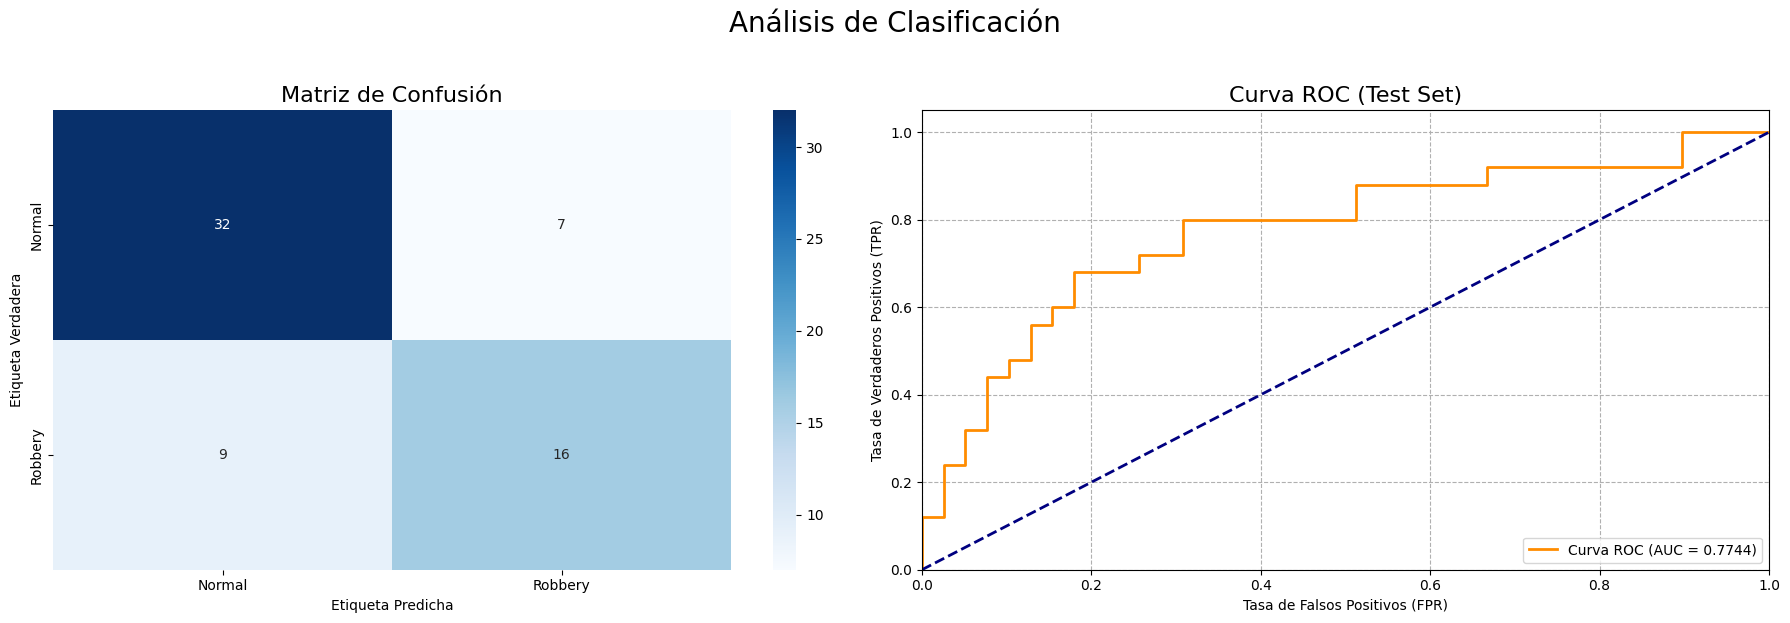

,Valor
Métrica,
loss,0.5305
accuracy,0.8036
precision,0.9375
recall,0.6000
f1_score,0.7317
auc,0.8684


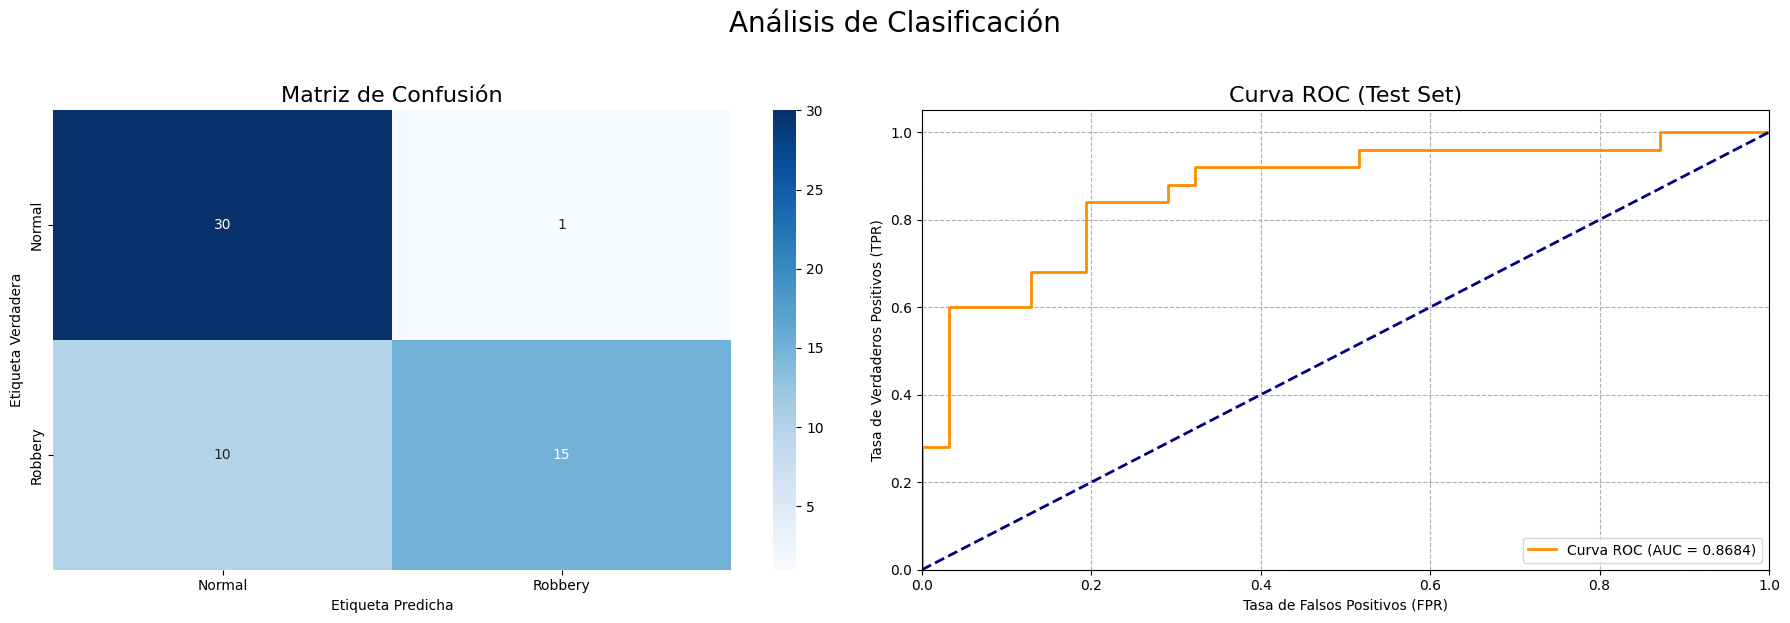

,Valor
Métrica,
loss,0.6370
accuracy,0.7679
precision,0.8750
recall,0.5600
f1_score,0.6829
auc,0.8671


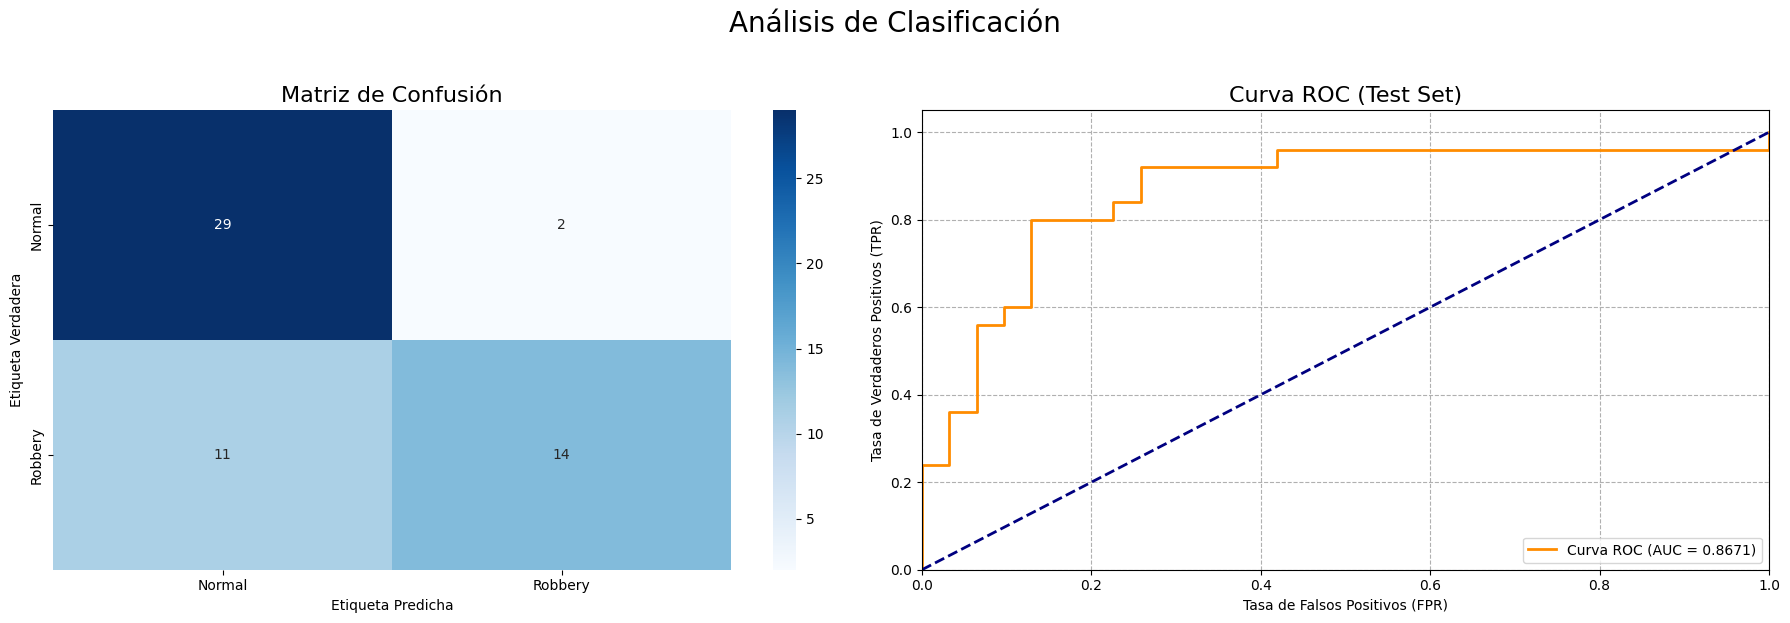

,Valor
Métrica,
loss,0.5325
accuracy,0.7679
precision,0.9286
recall,0.5200
f1_score,0.6667
auc,0.8490


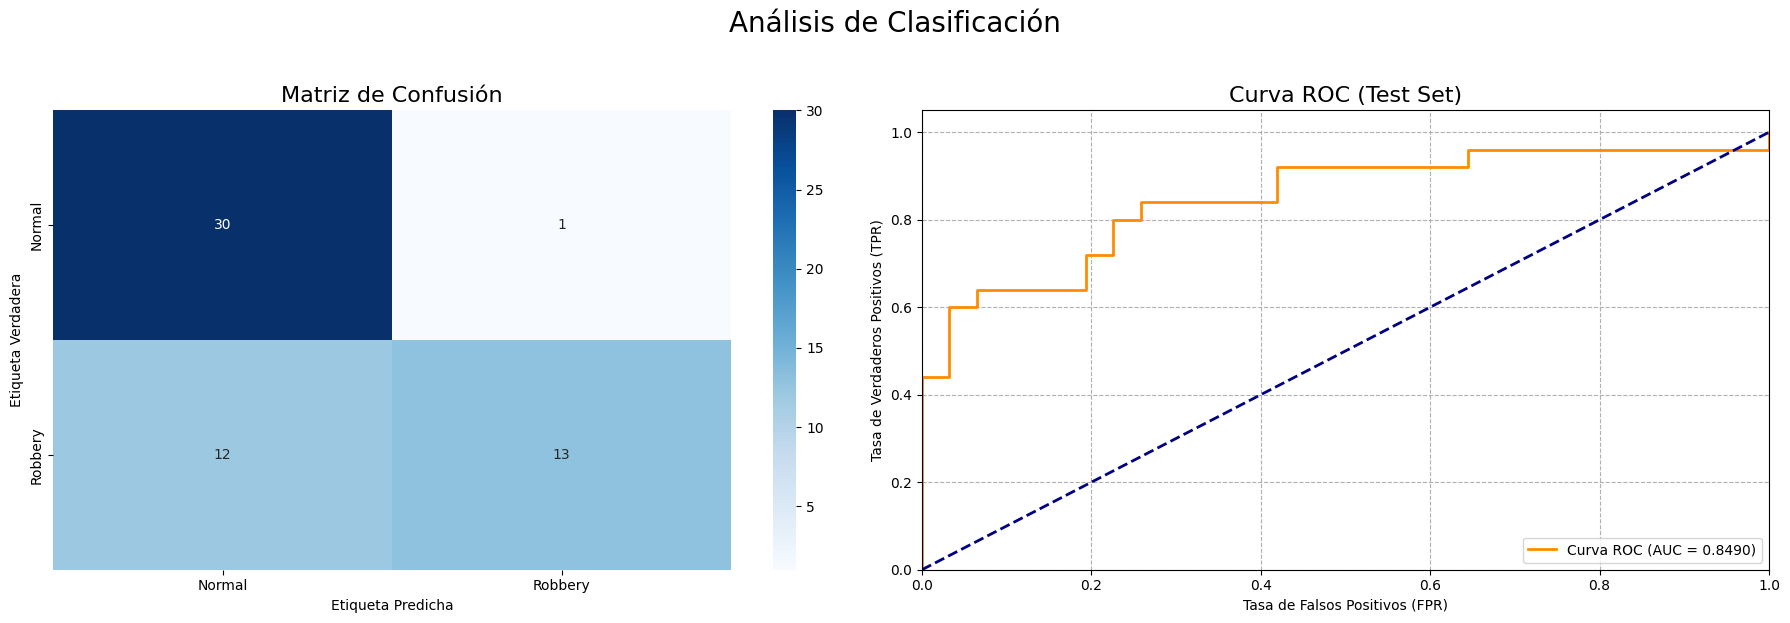

,Valor
Métrica,
loss,0.7976
accuracy,0.8036
precision,0.7692
recall,0.8000
f1_score,0.7843
auc,0.8103


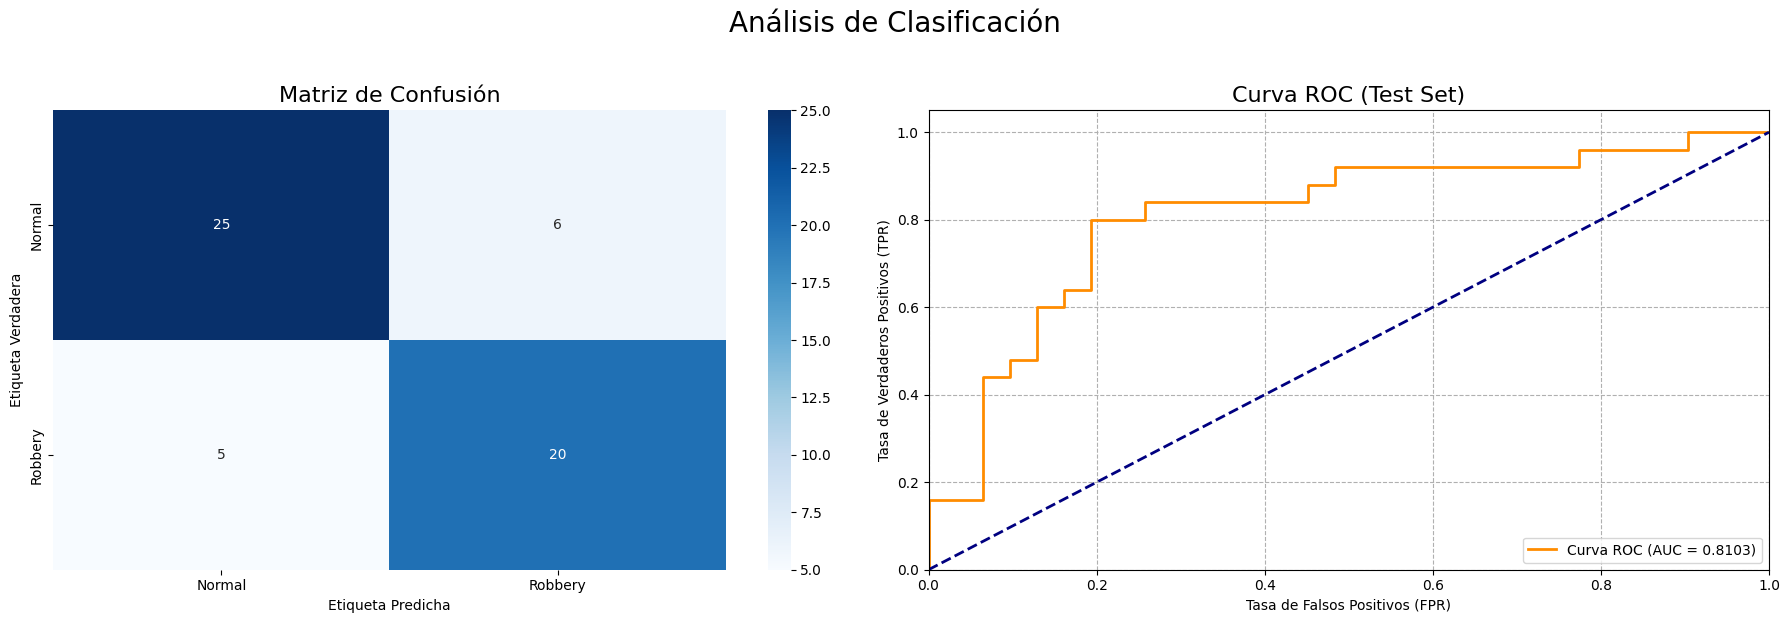

,Valor
Métrica,
loss,0.2738
accuracy,0.8451
precision,0.8621
recall,0.7812
f1_score,0.8197
auc,0.9095


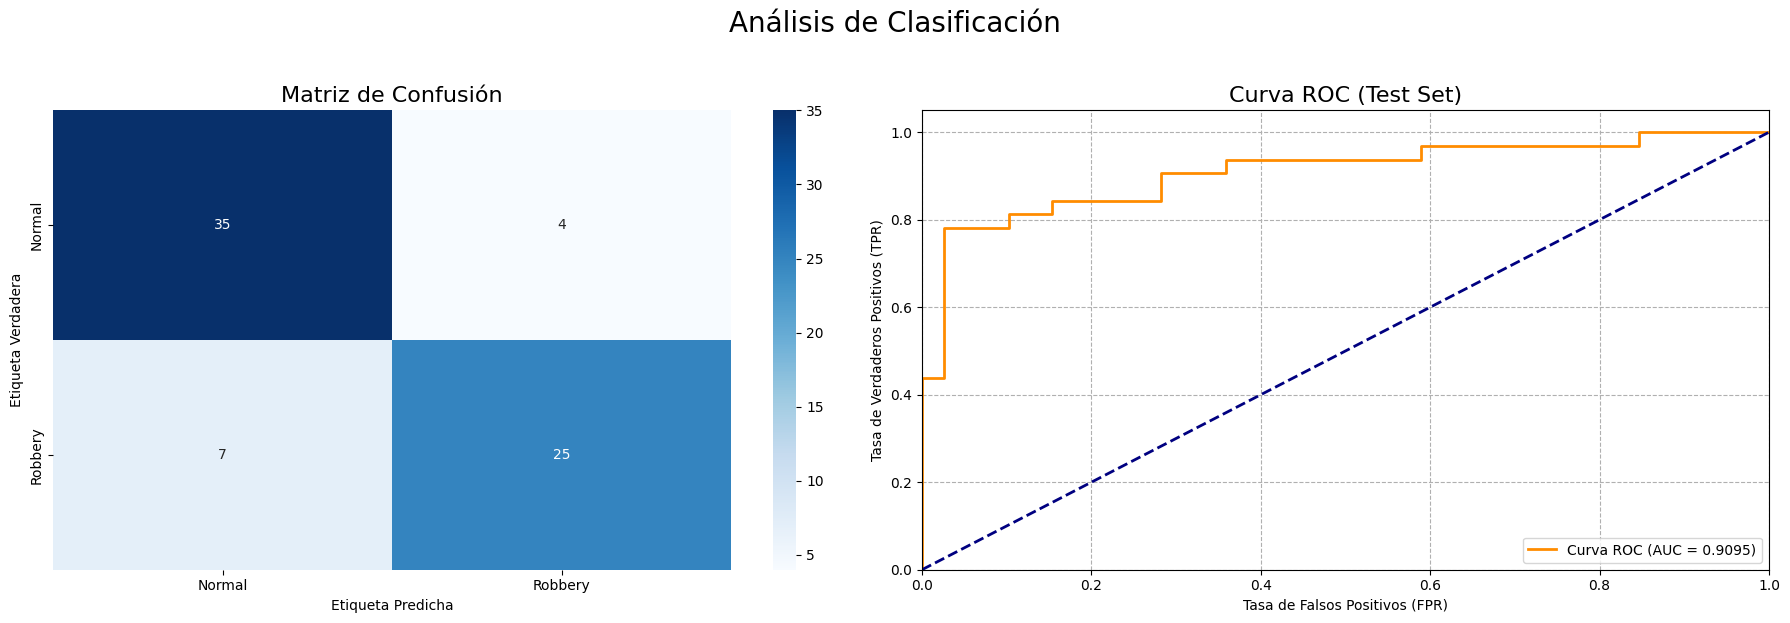

,Valor
Métrica,
loss,0.4676
accuracy,0.8028
precision,0.7045
recall,0.9688
f1_score,0.8158
auc,0.8902


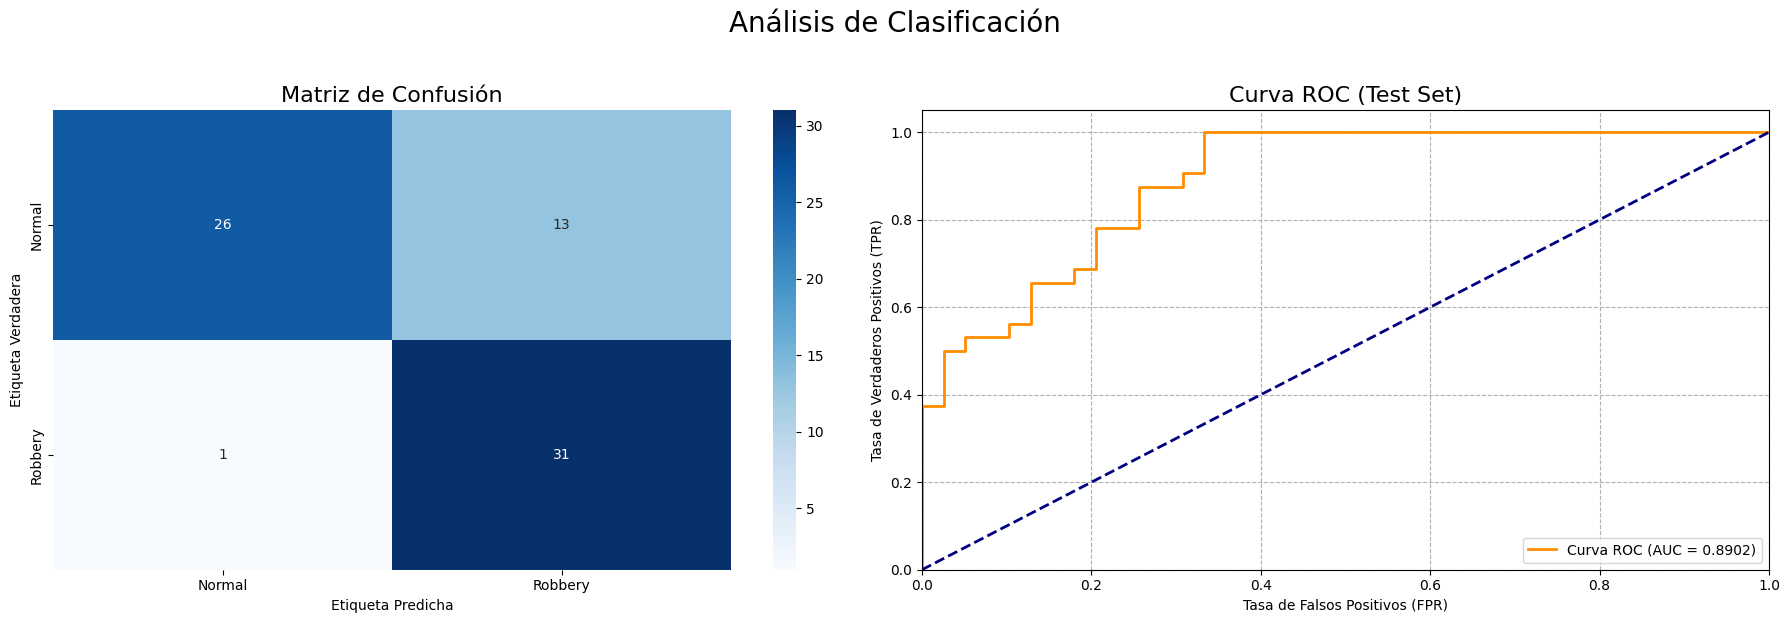

,Valor
Métrica,
loss,0.3915
accuracy,0.8310
precision,0.7632
recall,0.9062
f1_score,0.8286
auc,0.9103


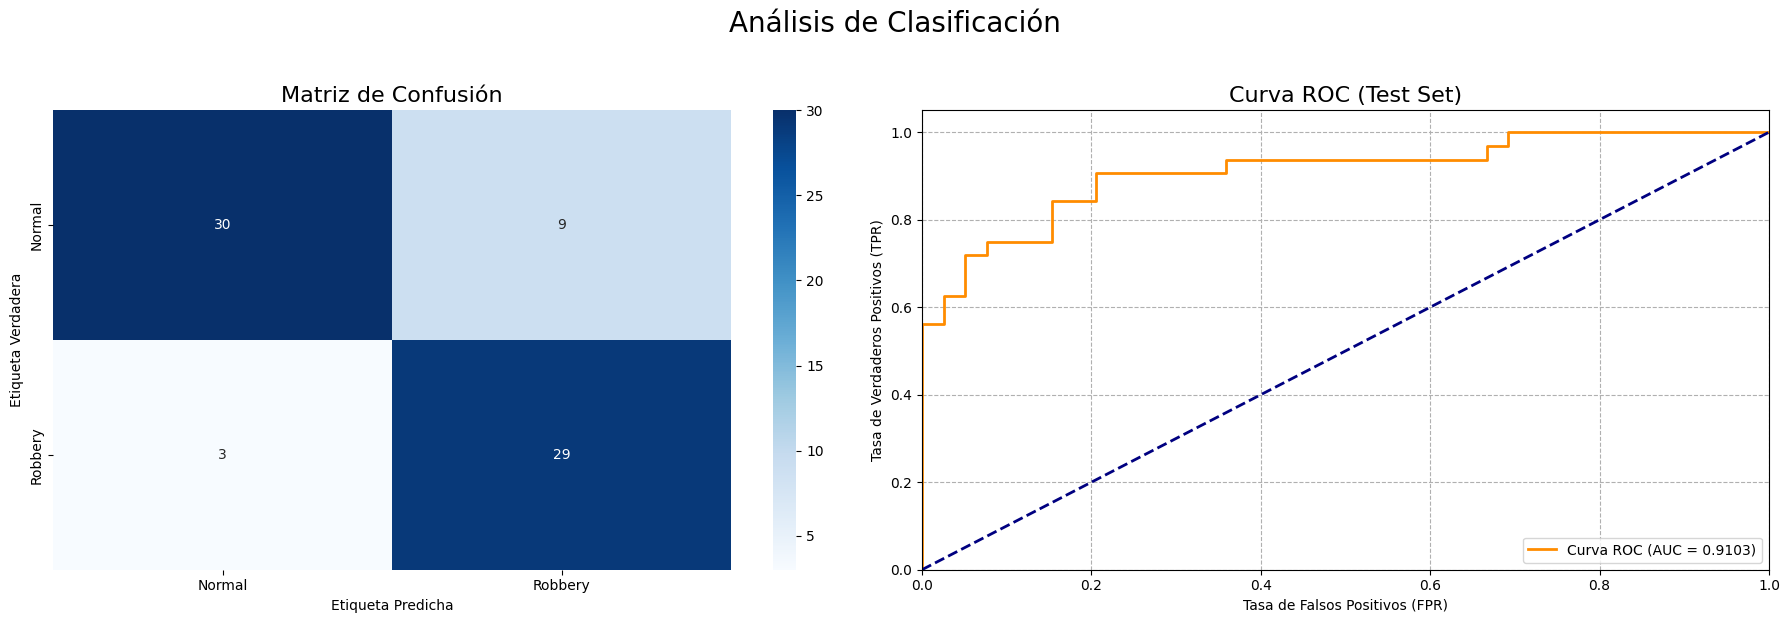

,Valor
Métrica,
loss,0.3375
accuracy,0.9014
precision,0.9310
recall,0.8438
f1_score,0.8852
auc,0.9303


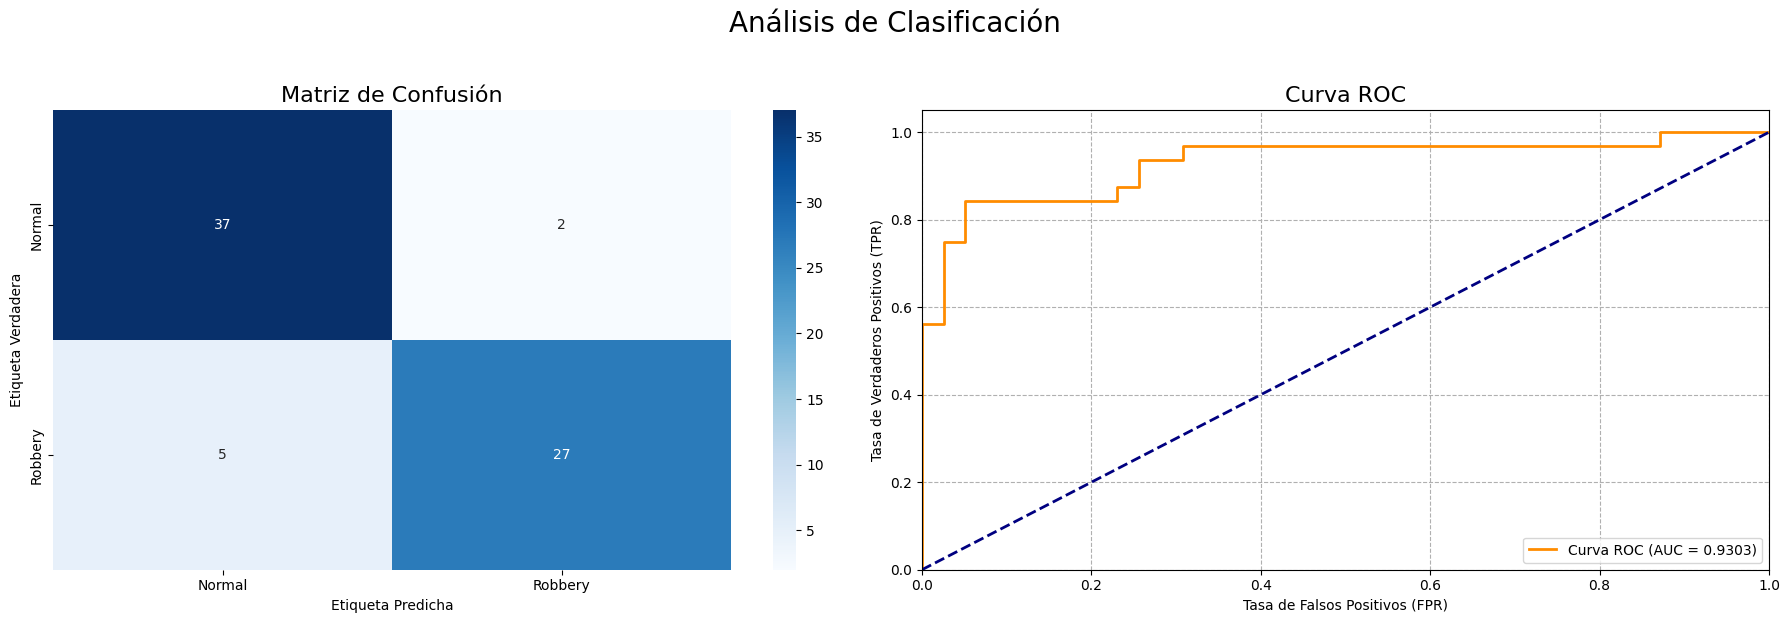

,Valor
Métrica,
loss,0.5991
accuracy,0.7812
precision,0.6897
recall,0.8000
f1_score,0.7407
auc,0.8605


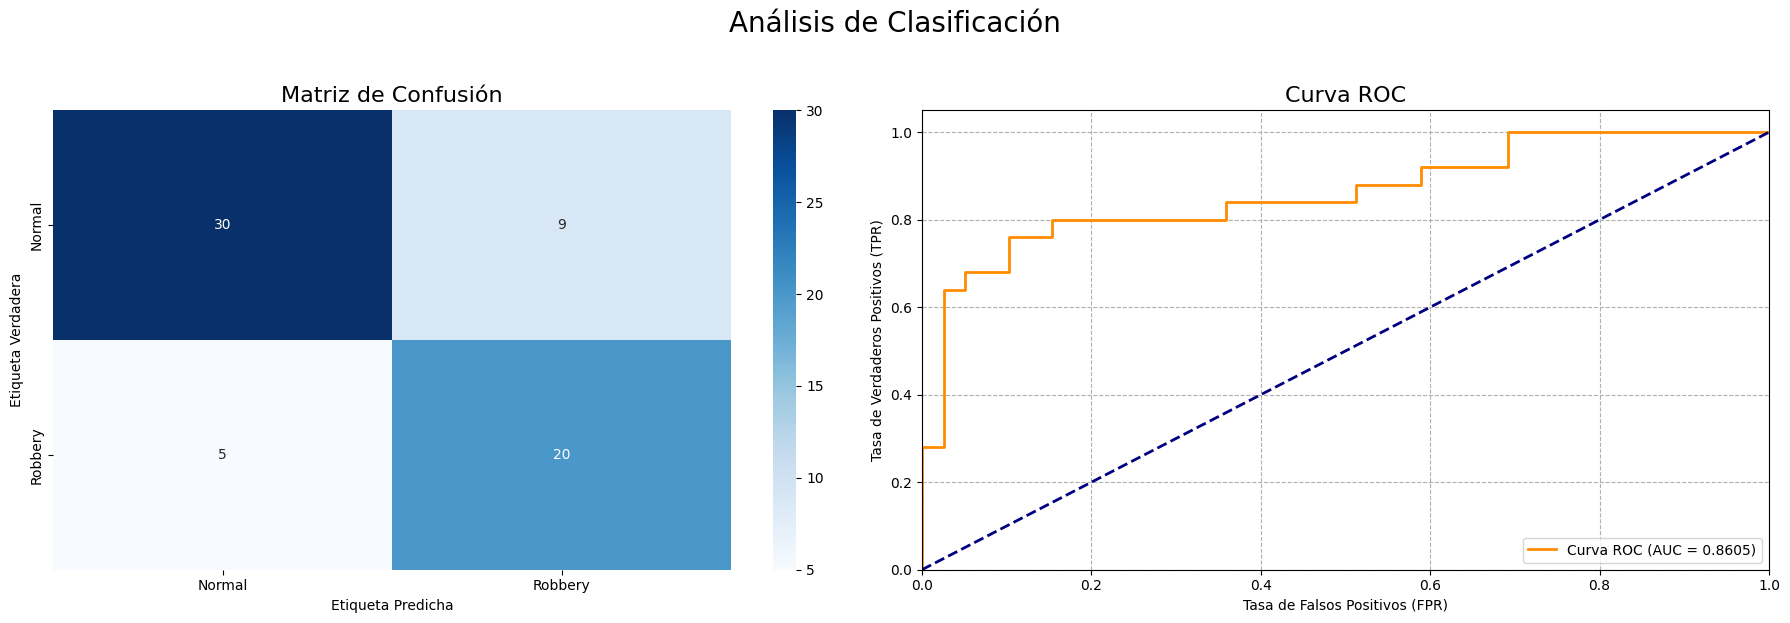

In [3]:
for artifact in experiment_artifacts:
    display(HTML(f"<h2>Resultados para: {artifact['name']}</h2>"))

    #métricas globales
    display(HTML("<h3>Métricas Globales de Test</h3>"))
    metrics_df = pd.DataFrame.from_dict(artifact['global_metrics'], orient='index', columns=['Valor'])
    metrics_df.index.name = 'Métrica'
    display(metrics_df.style.format({'Valor': '{:.4f}'}))

    #reporte de clasificación
    display(HTML("<h3>Reporte de Clasificación (Test)</h3>"))
    display(HTML(f"<pre>{artifact['classification_report']}</pre>"))

    #gráfico de análisis (matriz de confusión y Curva ROC)
    if artifact['plot_path']:
        display(HTML("<h3>Gráfico de Análisis</h3>"))
        display(Image(filename=artifact['plot_path'], width=900))
    
    display(HTML("<hr>"))

## Tabla Comparativa y Mejor Modelo

In [4]:
comparison_df = pd.DataFrame(all_metrics)
comparison_df = comparison_df.set_index('Experimento')

#criterio de ordenamiento
# mayor f1-score (robbery)
# mayor recall para menos falsos positivos
# mayor auc (test)
SORT_CRITERIA = ['F1 (Robbery)', 'Recall (Robbery)', 'AUC (Test)']

comparison_df_sorted = comparison_df.sort_values(
    by=SORT_CRITERIA,
    ascending=[False, False, False]
)

display(HTML("<h2>Tabla Comparativa de Experimentos (Ordenada por Mejor Rendimiento)</h2>"))
display(HTML("<p><b>Criterio de ordenamiento:</b> Máximo F1 (Robbery), luego Recall (Robbery), luego AUC.</p>"))

#tabla formateada
display(comparison_df_sorted.style.format({
    'AUC (Test)': '{:.4f}',
    'F1 (Robbery)': '{:.4f}',
    'Recall (Robbery)': '{:.4f}',
    'Precision (Robbery)': '{:.4f}',
    'Accuracy (Global)': '{:.4f}'
}).background_gradient(cmap='Greens', subset=SORT_CRITERIA))

,AUC (Test),F1 (Robbery),Recall (Robbery),Precision (Robbery),Accuracy (Global)
Experimento,,,,,
exp_12,0.9303,0.8852,0.8438,0.9310,0.9014
exp_11,0.9103,0.8286,0.9062,0.7632,0.8310
exp_09,0.9095,0.8197,0.7812,0.8621,0.8451
exp_10,0.8902,0.8158,0.9688,0.7045,0.8028
exp_08,0.8103,0.7843,0.8000,0.7692,0.8036
exp_02,0.8667,0.7547,0.8000,0.7143,0.7969
exp_03,0.7887,0.7451,0.7600,0.7308,0.7969
exp_13,0.8605,0.7407,0.8000,0.6897,0.7812
exp_05,0.8684,0.7317,0.6000,0.9375,0.8036


In [5]:
best_exp_name = comparison_df_sorted.index[0]
best_recall = comparison_df_sorted.iloc[0]['Recall (Robbery)']
best_f1 = comparison_df_sorted.iloc[0]['F1 (Robbery)']
best_auc = comparison_df_sorted.iloc[0]['AUC (Test)']

display(Markdown(f"""
## Conclusión del mejor experimento

Basado en el criterio de priorizar la reducción de falsos negativos (mayor recall) sin  sacrificar la media armónica entre recall y precisión (F1-Score), el mejor modelo es:

**`{best_exp_name}`**

Este experimento logró:
* **Recall (Robbery):** {best_recall:.4f}
* **F1-Score (Robbery):** {best_f1:.4f}
* **AUC (Test):** {best_auc:.4f}
"""))


## Conclusión del mejor experimento

Basado en el criterio de priorizar la reducción de falsos negativos (mayor recall) sin  sacrificar la media armónica entre recall y precisión (F1-Score), el mejor modelo es:

**`exp_12`**

Este experimento logró:
* **Recall (Robbery):** 0.8438
* **F1-Score (Robbery):** 0.8852
* **AUC (Test):** 0.9303
